In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from matplotlib import pyplot as plt
import seaborn as sns
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = None
pd.options.display.max_columns = None

In [ ]:
import kagglehub
import pandas as pd
import os
import numpy as np

# 1. Download the latest version
path = kagglehub.dataset_download("sharmajicoder/gaming-and-mental-health")

# 2. Locate the CSV file
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

print(f"File found: {csv_file}")

100%|██████████| 66.4M/66.4M [00:00<00:00, 231MB/s]


Extracting files...
File found: gaming_mental_health_10M_40features.csv


In [ ]:
import numpy as np
import pandas as pd

def optimize_df(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                else:
                    df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.float32)
    return df

# Load the entire CSV file
df = pd.read_csv(full_path)
# Optimize the DataFrame
df = optimize_df(df)

print(f"Success! Loaded {len(df):,} rows.")

Success! Loaded 1,000,000 rows.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 39 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   age                         1000000 non-null  int8   
 1   gender                      1000000 non-null  object 
 2   income                      1000000 non-null  int32  
 3   daily_gaming_hours          1000000 non-null  float32
 4   weekly_sessions             1000000 non-null  int8   
 5   years_gaming                1000000 non-null  int8   
 6   sleep_hours                 1000000 non-null  float32
 7   caffeine_intake             1000000 non-null  float32
 8   exercise_hours              1000000 non-null  float32
 9   stress_level                1000000 non-null  int8   
 10  anxiety_score               1000000 non-null  float32
 11  depression_score            1000000 non-null  float32
 12  social_interaction_score    1000000 non-null  float32
 13

In [ ]:
df.describe()


,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,depression_score,social_interaction_score,relationship_satisfaction,academic_performance,work_productivity,addiction_level,multiplayer_ratio,toxic_exposure,violent_games_ratio,mobile_gaming_ratio,night_gaming_ratio,weekend_gaming_hours,friends_gaming_count,online_friends,streaming_hours,esports_interest,headset_usage,microtransactions_spending,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
count,"1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00"
mean,35.99,"77,497.68",4.00,20.00,12.00,7.00,2.00,2.00,5.50,5.00,5.00,5.99,5.99,69.86,69.85,2.82,0.50,0.29,0.40,0.50,0.50,6.00,24.51,249.63,2.00,5.00,0.50,500.48,5.00,5.00,5.00,5.98,24.00,8.00,5.00,4.02,49.45,5.50
std,13.56,"41,851.54",2.83,11.25,7.21,1.50,2.00,2.00,2.87,1.98,2.40,1.96,1.96,14.70,14.69,2.11,0.22,0.16,0.20,0.22,0.22,4.24,14.44,144.36,1.42,3.16,0.50,499.45,3.16,1.98,1.98,1.96,4.00,4.00,1.98,1.96,28.87,2.87
min,13.00,"5,000.00",0.00,1.00,0.00,-0.17,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.45,0.07,0.00,0.00,0.00,1.00
25%,24.00,"41,258.00",1.92,10.00,6.00,5.99,0.58,0.58,3.00,3.65,3.31,4.65,4.65,59.89,59.88,1.25,0.33,0.16,0.24,0.33,0.33,2.88,12.00,124.00,0.96,2.00,0.00,144.24,2.00,3.65,3.65,4.65,21.30,5.07,3.65,2.66,24.00,3.00
50%,36.00,"77,521.00",3.36,20.00,12.00,7.00,1.39,1.39,5.00,5.00,5.00,6.00,6.00,69.97,69.98,2.46,0.50,0.26,0.39,0.50,0.50,5.03,25.00,250.00,1.68,5.00,0.00,347.37,5.00,5.00,5.00,6.00,24.00,7.35,5.00,4.00,49.00,6.00
75%,48.00,"113,697.00",5.38,30.00,18.00,8.01,2.77,2.77,8.00,6.35,6.69,7.35,7.35,80.10,80.10,3.99,0.67,0.39,0.54,0.67,0.67,8.07,37.00,375.00,2.70,8.00,1.00,694.37,8.00,6.35,6.35,7.35,26.70,10.22,6.35,5.35,74.00,8.00
max,59.00,"149,999.00",30.42,39.00,24.00,14.02,26.90,26.48,10.00,10.00,10.00,10.00,10.00,100.00,100.00,10.00,1.00,0.95,0.99,1.00,1.00,51.20,49.00,499.00,17.15,10.00,1.00,"6,581.12",10.00,10.00,10.00,10.00,43.60,46.60,10.00,10.00,99.00,10.00


In [ ]:
# Min Sleeping Hours must be 0
df.loc[df['sleep_hours'] < 0, 'sleep_hours'] = 0

In [ ]:
# Fix Daily Time-based features (Max 24 hours)
# This applies to daily gaming and screen time
max_limit = 24.0
df.loc[df['daily_gaming_hours'] > max_limit, 'daily_gaming_hours'] = max_limit

# Result
print(f"Max_Playing_Hours: {df['daily_gaming_hours'].max()}")

Max_Playing_Hours: 24.0


In [ ]:
# Fix Weekend Gaming (Max 48 hours for 2 days)
df.loc[df['weekend_gaming_hours'] > 48, 'weekend_gaming_hours'] = 48

**Gaming Behavior KPIs**


Addiction Users %: Measures the percentage of users whose addiction scores exceed a critical threshold, identifying at-risk populations.

Average Daily Gaming Hours: Tracks the mean number of hours users spend gaming daily to measure overall time investment.

Night Gaming Ratio: Identifies users who may be sacrificing sleep for gaming by calculating the percentage of play that occurs at night.

In [ ]:
# Addiction Users %
# threshold = <75% (3.99)
threshold = 3
high_addiction_score = df['addiction_level'] > threshold
high_addiction_count = high_addiction_score.sum()
total_users = len(df)
high_addiction_percentage = (high_addiction_count / total_users) * 100
print(f"High Addiction Users: {high_addiction_percentage}")

High Addiction Users: 39.779199999999996


In [ ]:
#Average Daily Gaming Hours
average_daily_gaming_hours = df['daily_gaming_hours'].mean()
print(f"Average Daily Gaming Hours: {average_daily_gaming_hours}")


Average Daily Gaming Hours: 3.999177932739258


In [ ]:
# Night gaming Ratio
night_gaming_rat = df['night_gaming_ratio'].mean()
print(f"Night Gaming Ratio: {night_gaming_rat}")
# percent
Night_Gaming_Percent =night_gaming_rat* 100
print(f"Night Gaming Percent: {Night_Gaming_Percent}")

Night Gaming Ratio: 0.5002762079238892
Night Gaming Percent: 50.02762222290039


### *Mental Health KPIs*

- Mental Health Risk Index:A composite Z-score combining stress, anxiety, depression, and loneliness into a single measure of psychological well-being.
- Average Happiness Score:* Measures the population's baseline for positive mental health and life satisfaction
- Average Stress Level:* Tracks the overall stress burden within the gaming community

In [ ]:
from scipy import stats

# 1. Define the four columns that make up the index
columns_to_index = ['stress_level', 'anxiety_score', 'depression_score', 'loneliness_score']

# 2. Calculate Z-scores for each column
# This transforms the values so they have a Mean of 0 and Standard Deviation of 1
z_scores = df[columns_to_index].apply(stats.zscore)

# 3. Create the Mental Health Risk Index
# We sum the Z-scores across the row and divide by 4
df['mental_health_risk_index'] = z_scores.sum(axis=1) / 4

# 4. View the results
print("Mental Health Risk Index created successfully!")
print(df[['stress_level', 'anxiety_score','depression_score', 'loneliness_score', 'mental_health_risk_index']].head())

# 5. Summarize the KPI
print("\n--- KPI Summary ---")
print(df['mental_health_risk_index'].describe())

Mental Health Risk Index created successfully!
   stress_level  anxiety_score  depression_score  loneliness_score  \
0             3           4.06              5.02              2.87   
1             8           6.76              7.63              4.17   
2             3           9.57              4.02              9.38   
3             1           4.97              1.40              8.24   
4             2           8.73              4.83              6.65   

   mental_health_risk_index  
0                     -0.60  
1                      0.61  
2                      0.81  
3                     -0.36  
4                      0.36  

--- KPI Summary ---
count   1,000,000.00
mean            0.00
std             0.50
min            -2.18
25%            -0.34
50%             0.00
75%             0.34
max             2.12
Name: mental_health_risk_index, dtype: float64


Risk Buckeys (Low, Moderate, High Risk)
  **Status of each user**

--- Risk Level Distribution ---
Moderate Risk: 67.72% (677,165 users)
Low Risk: 16.15% (161,499 users)
High Risk: 16.13% (161,336 users)


/tmp/ipykernel_21958/3714832519.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Risk_Level', palette='viridis', order=['Low Risk', 'Moderate Risk', 'High Risk'])


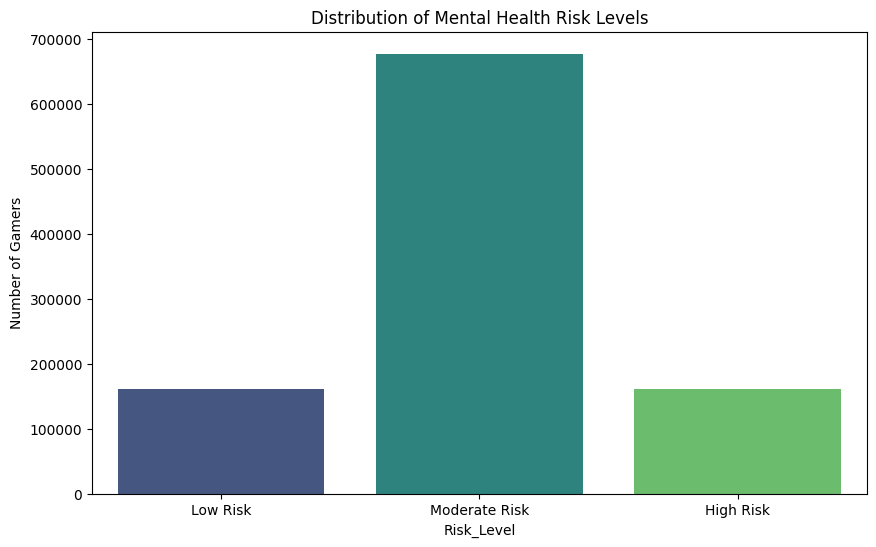

In [ ]:

# 1. Define the function to categorize risk based on the Z-score distribution
def segment_risk(score):
    if score <= -0.5:
        return 'Low Risk'
    elif -0.5 < score <= 0.5:
        return 'Moderate Risk'
    else:
        return 'High Risk'

# 2. Create the new column 'Risk_Level'
df['Risk_Level'] = df['mental_health_risk_index'].apply(segment_risk)

# 3. Calculate the distribution (The values for your Pie Chart)
risk_counts = df['Risk_Level'].value_counts()
risk_percentages = df['Risk_Level'].value_counts(normalize=True) * 100

print("--- Risk Level Distribution ---")
for level, percent in risk_percentages.items():
    print(f"{level}: {percent:.2f}% ({risk_counts[level]:,} users)")

# 4. Quick Visualization for your report
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Risk_Level', palette='viridis', order=['Low Risk', 'Moderate Risk', 'High Risk'])
plt.title('Distribution of Mental Health Risk Levels')
plt.ylabel('Number of Gamers')
plt.show()

Average Happiness score

--- Positive KPI: Average Happiness Score ---
Population Baseline: 5.98 / 10

--- Happiness by Risk Segment ---
Risk_Level
Low Risk        5.98
Moderate Risk   5.98
High Risk       5.99
Name: happiness_score, dtype: float32


/tmp/ipykernel_21958/590802952.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=happiness_by_risk.index, y=happiness_by_risk.values, palette='RdYlGn')


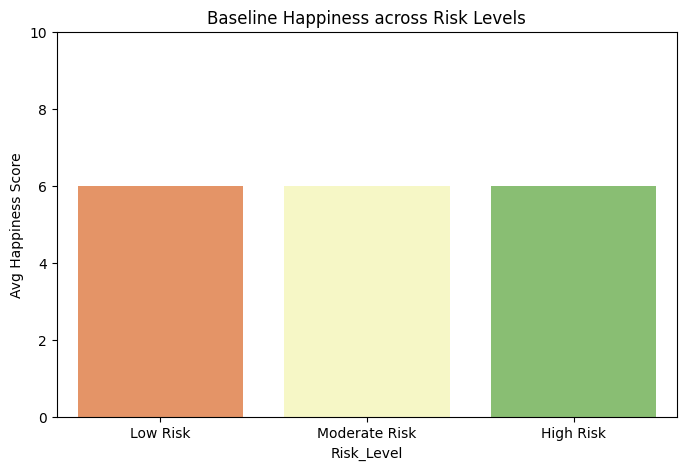

In [ ]:
# 1. Calculate the Global Average Happiness Score
average_happiness = df['happiness_score'].mean()

# 2. Calculate Happiness per Risk Level (to show the impact of mental health)
happiness_by_risk = df.groupby('Risk_Level')['happiness_score'].mean().sort_values()

# 3.the Results
print(f"--- Positive KPI: Average Happiness Score ---")
print(f"Population Baseline: {average_happiness:.2f} / 10")
print("\n--- Happiness by Risk Segment ---")
print(happiness_by_risk)

# Dashboard
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x=happiness_by_risk.index, y=happiness_by_risk.values, palette='RdYlGn')
plt.title('Baseline Happiness across Risk Levels')
plt.ylabel('Avg Happiness Score')
plt.ylim(0, 10) # Assuming the scale is 0-10
plt.show()

**Average Stress Level**
this average against the Mental Health Risk Indexr, to see if stress is the primary driver of risk.


*  If the average is above 5, the community is leaning toward a high-stress environment.


*   If the average is below 5, gaming may be serving as a successful stress-relief mechanism for the majority.




--- Psychological KPI: Average Stress Level ---
Global Community Average: 5.50 / 10

--- Stress Level by Risk Category ---
Risk_Level
High Risk       7.66
Low Risk        3.34
Moderate Risk   5.50
Name: stress_level, dtype: float64


/tmp/ipykernel_21958/1102468281.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Level', y='stress_level', data=df, palette='magma')


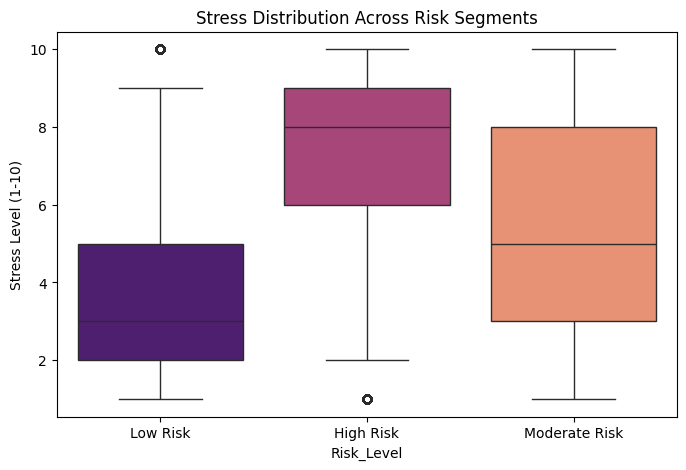

In [ ]:
# 1. Calculate the Global Average Stress Level
avg_stress = df['stress_level'].mean()

# 2. Compare Stress: Balanced Gamers vs. High Risk Gamers
# This adds "Depth" to your KPI for the presentation
stress_comparison = df.groupby('Risk_Level')['stress_level'].mean()

# 3. Print the Results
print(f"--- Psychological KPI: Average Stress Level ---")
print(f"Global Community Average: {avg_stress:.2f} / 10")
print("\n--- Stress Level by Risk Category ---")
print(stress_comparison)

# 4. Visualize for your "Psychological Health" Dashboard Page
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x='Risk_Level', y='stress_level', data=df, palette='magma')
plt.title('Stress Distribution Across Risk Segments')
plt.ylabel('Stress Level (1-10)')
plt.show()

**The Gaming Impact Score**
 It is the most complex and important metric because it doesn’t just look at how long someone plays; it looks at the consequences of that play.
 it is an executive metric that balances gaming intensity, sleep reduction, stress elevation, and productivity loss.

In [ ]:
# 1. Prepare the components
# We want to scale these 0-100 so we can average them
def scale_column(col):
    return (col - col.min()) / (col.max() - col.min()) * 100

# 2. Invert columns where 'lower is worse'
# For Sleep and Productivity, a LOW number means a HIGH negative impact
inv_sleep = 100 - scale_column(df['sleep_hours'])
inv_prod = 100 - scale_column(df['work_productivity'])

# 3. Scale columns where 'higher is worse'
gaming_scaled = scale_column(df['daily_gaming_hours'])
mental_scaled = scale_column(df['mental_health_risk_index'])

# 4. Calculate the Final Gaming Impact Score
# This is the average of all four negative impacts
df['gaming_impact_score'] = (gaming_scaled + mental_scaled + inv_sleep + inv_prod) / 4

print("--- Gaming Impact Score Created ---")
print(df['gaming_impact_score'].describe())

# Show a sample of the results
print("\nSample Results (First 5 users):")
print(df[['daily_gaming_hours', 'mental_health_risk_index', 'gaming_impact_score']].head())

--- Gaming Impact Score Created ---
count   1,000,000.00
mean           36.89
std             6.15
min             6.48
25%            32.68
50%            36.73
75%            40.92
max            77.54
Name: gaming_impact_score, dtype: float64

Sample Results (First 5 users):
   daily_gaming_hours  mental_health_risk_index  gaming_impact_score
0                3.68                     -0.60                34.33
1                5.70                      0.61                44.52
2                1.58                      0.81                42.18
3                6.11                     -0.36                30.55
4                3.65                      0.36                38.66


**Gaming Impact Score**

Score 0-30: Low Impact. Gaming is a healthy hobby for these users; it doesn't hurt their sleep or work.

Score 31-60: Moderate Impact. Gaming is starting to displace sleep or cause minor stress.

Score 61-100: High Impact. This is the "Danger Zone." These users are experiencing a significant negative "impact" on their actual life.

**Academic Drop-off Point" (GPA vs. Gaming Hours)**

--- Productivity Insight ---
The Academic Drop-off Point is approximately: nan hours per day


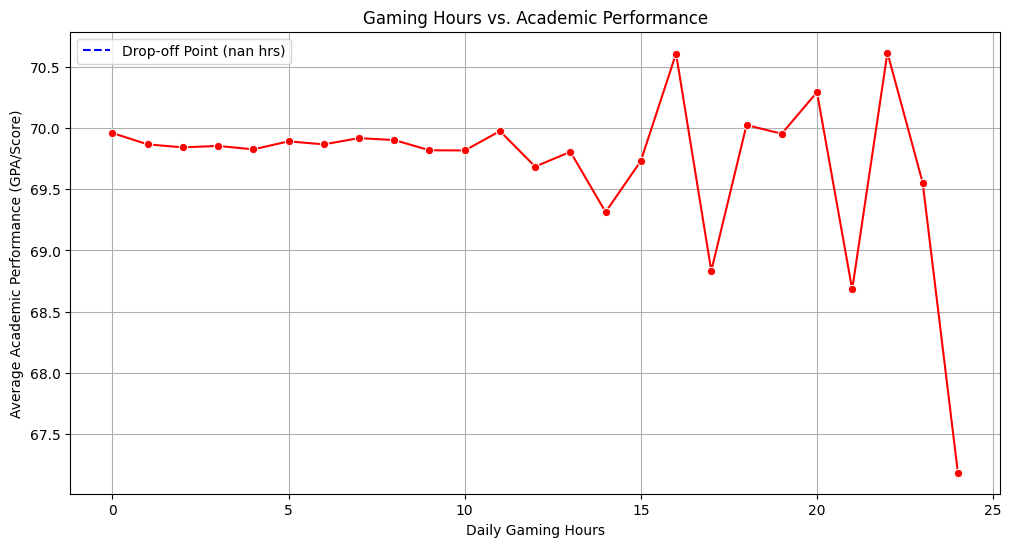

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Round gaming hours to the nearest whole number to create clean groups
df['gaming_hours_rounded'] = df['daily_gaming_hours'].round()

# 2. Calculate average GPA/Academic performance for each hour group
academic_trend = df.groupby('gaming_hours_rounded')['academic_performance'].mean().reset_index()

# 3. Find the Drop-off Point
# We look for the hour where academic performance drops below the 10th percentile of the average
overall_avg = df['academic_performance'].mean()
drop_off_point = academic_trend[academic_trend['academic_performance'] < (overall_avg * 0.95)]['gaming_hours_rounded'].min()

print(f"--- Productivity Insight ---")
print(f"The Academic Drop-off Point is approximately: {drop_off_point} hours per day")

# 4. Visualize the "Slippery Slope"
plt.figure(figsize=(12, 6))
sns.lineplot(data=academic_trend, x='gaming_hours_rounded', y='academic_performance', marker='o', color='red')
plt.axvline(x=drop_off_point, color='blue', linestyle='--', label=f'Drop-off Point ({drop_off_point} hrs)')

plt.title('Gaming Hours vs. Academic Performance')
plt.xlabel('Daily Gaming Hours')
plt.ylabel('Average Academic Performance (GPA/Score)')
plt.legend()
plt.grid(True)
plt.show()

"Balanced Gamer":
a user must meet four healthy criteria simultaneously:

  1- Moderate Play: Not excessive gaming (e.g.,< 4 hours/day).
  2- Healthy Sleep: Getting enough rest (e.g., >/= 7 hours).
  3 - Physical Activity: Engaging in exercise (e.g., >/= 1 hour).
  4-Social Connection: Maintaining a high social interaction score (e.g., > 5/10).



In [ ]:
# 1. Define the "Healthy Thresholds" based on your dataset averages
max_gaming_hours = 4
min_sleep_hours = 7
min_exercise_hours = 1
min_social_score = 5

# 2. Create a "Boolean Mask" (True/False) for each condition
is_moderate_gamer = df['daily_gaming_hours'] <= max_gaming_hours
is_well_rested = df['sleep_hours'] >= min_sleep_hours
is_active = df['exercise_hours'] >= min_exercise_hours
is_social = df['social_interaction_score'] >= min_social_score

# 3. Identify the "Balanced Gamers" (must meet ALL conditions)
df['is_balanced_gamer'] = is_moderate_gamer & is_well_rested & is_active & is_social

# 4. Calculate the KPI Percentage
balanced_gamer_count = df['is_balanced_gamer'].sum()
total_users = len(df)
balanced_gamer_percent = (balanced_gamer_count / total_users) * 100

print(f"--- Positive KPI: Balanced Gamer Score ---")
print(f"Total Users: {total_users:,}")
print(f"Number of Balanced Gamers: {balanced_gamer_count:,}")
print(f"Balanced Gamer Score: {balanced_gamer_percent:.2f}%")

--- Positive KPI: Balanced Gamer Score ---
Total Users: 1,000,000
Number of Balanced Gamers: 125,311
Balanced Gamer Score: 12.53%
